<a href="https://colab.research.google.com/github/hsarrah-create/Assignment-1/blob/main/Ass1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pm4py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 41.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import pm4py

df_full = pd.read_csv("derived_event_log_complaint_management.csv")

print("Number of rows:", len(df_full))
print("Number of cases:", df_full["Case ID"].nunique())
print(df_full.head())



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




Number of rows: 85284
Number of cases: 21321
      Case ID                  Activity        Timestamp  \
0  6168884918              Order Placed  9/10/2024 23:38   
1  6168884918  Ready Marked - Correctly  9/10/2024 23:56   
2  6168884918  Order Status - Delivered              NaN   
3  6168884918              No Complaint              NaN   
4  6170707559              Order Placed  9/10/2024 23:34   

                       Timestamp Type  Event Order  
0                            Observed            1  
1  Derived from Order Placed At + KPT            2  
2             Not available in source            3  
3             Not available in source            4  
4                            Observed            1  


In [ ]:
from pm4py.objects.log.obj import EventLog, Trace, Event

df_full = df_full.sort_values(["Case ID", "Event Order"])

full_log = EventLog()

for case_id, group in df_full.groupby("Case ID", sort=False):
    trace = Trace(attributes={"concept:name": str(case_id)})

    for _, row in group.iterrows():
        trace.append(Event({
            "concept:name": row["Activity"]
        }))

    full_log.append(trace)

print("Number of cases:", len(full_log))

Number of cases: 21321


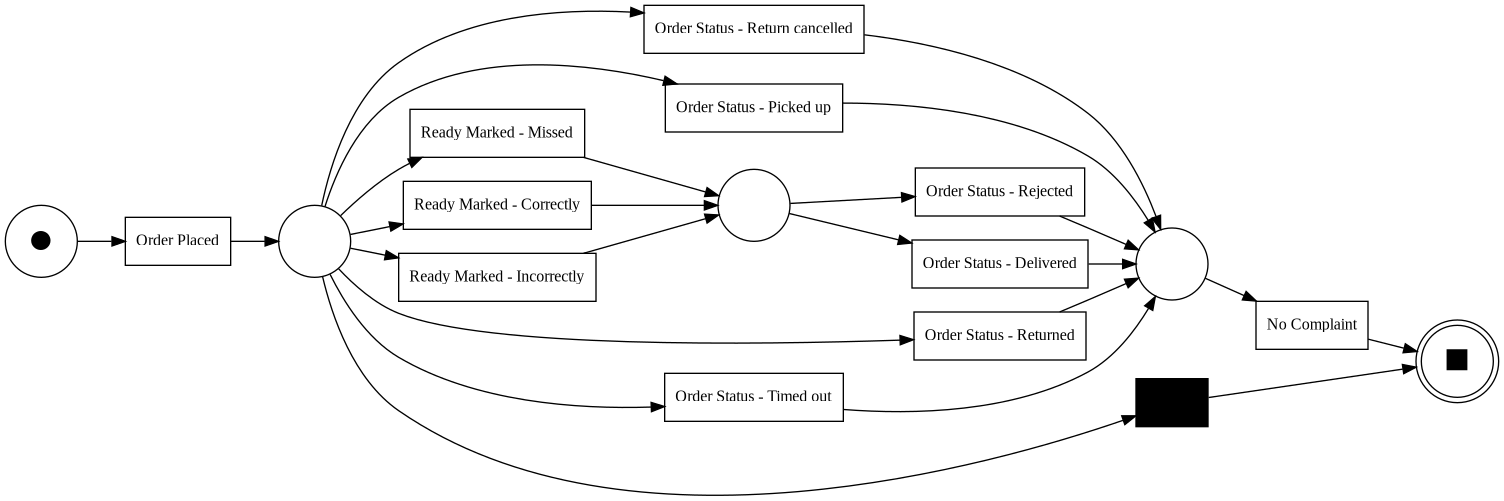

Places: 5
Transitions: 12
Arcs: 24


In [ ]:
net_full, initial_marking_full, final_marking_full = \
    pm4py.discover_petri_net_inductive(
        full_log,
        noise_threshold=0.2
    )

pm4py.view_petri_net(
    net_full,
    initial_marking_full,
    final_marking_full
)

print("Places:", len(net_full.places))
print("Transitions:", len(net_full.transitions))
print("Arcs:", len(net_full.arcs))

In [ ]:
fitness = pm4py.fitness_token_based_replay(
    full_log,
    net_full,
    initial_marking_full,
    final_marking_full
)

precision = pm4py.precision_token_based_replay(
    full_log,
    net_full,
    initial_marking_full,
    final_marking_full
)

generalization = pm4py.generalization_tbr(
    full_log,
    net_full,
    initial_marking_full,
    final_marking_full
)

simplicity = pm4py.simplicity_petri_net(
    net_full,
    initial_marking_full,
    final_marking_full
)

print("Fitness:", fitness["log_fitness"])
print("Precision:", precision)
print("Generalisation:", generalization)
print("Simplicity:", simplicity)

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/16 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

Fitness: 0.9952796412150449
Precision: 0.6363140141322564
Generalisation: 0.7050473594790507
Simplicity: 0.5483870967741935


Places: 12
Transitions: 26
Arcs: 52


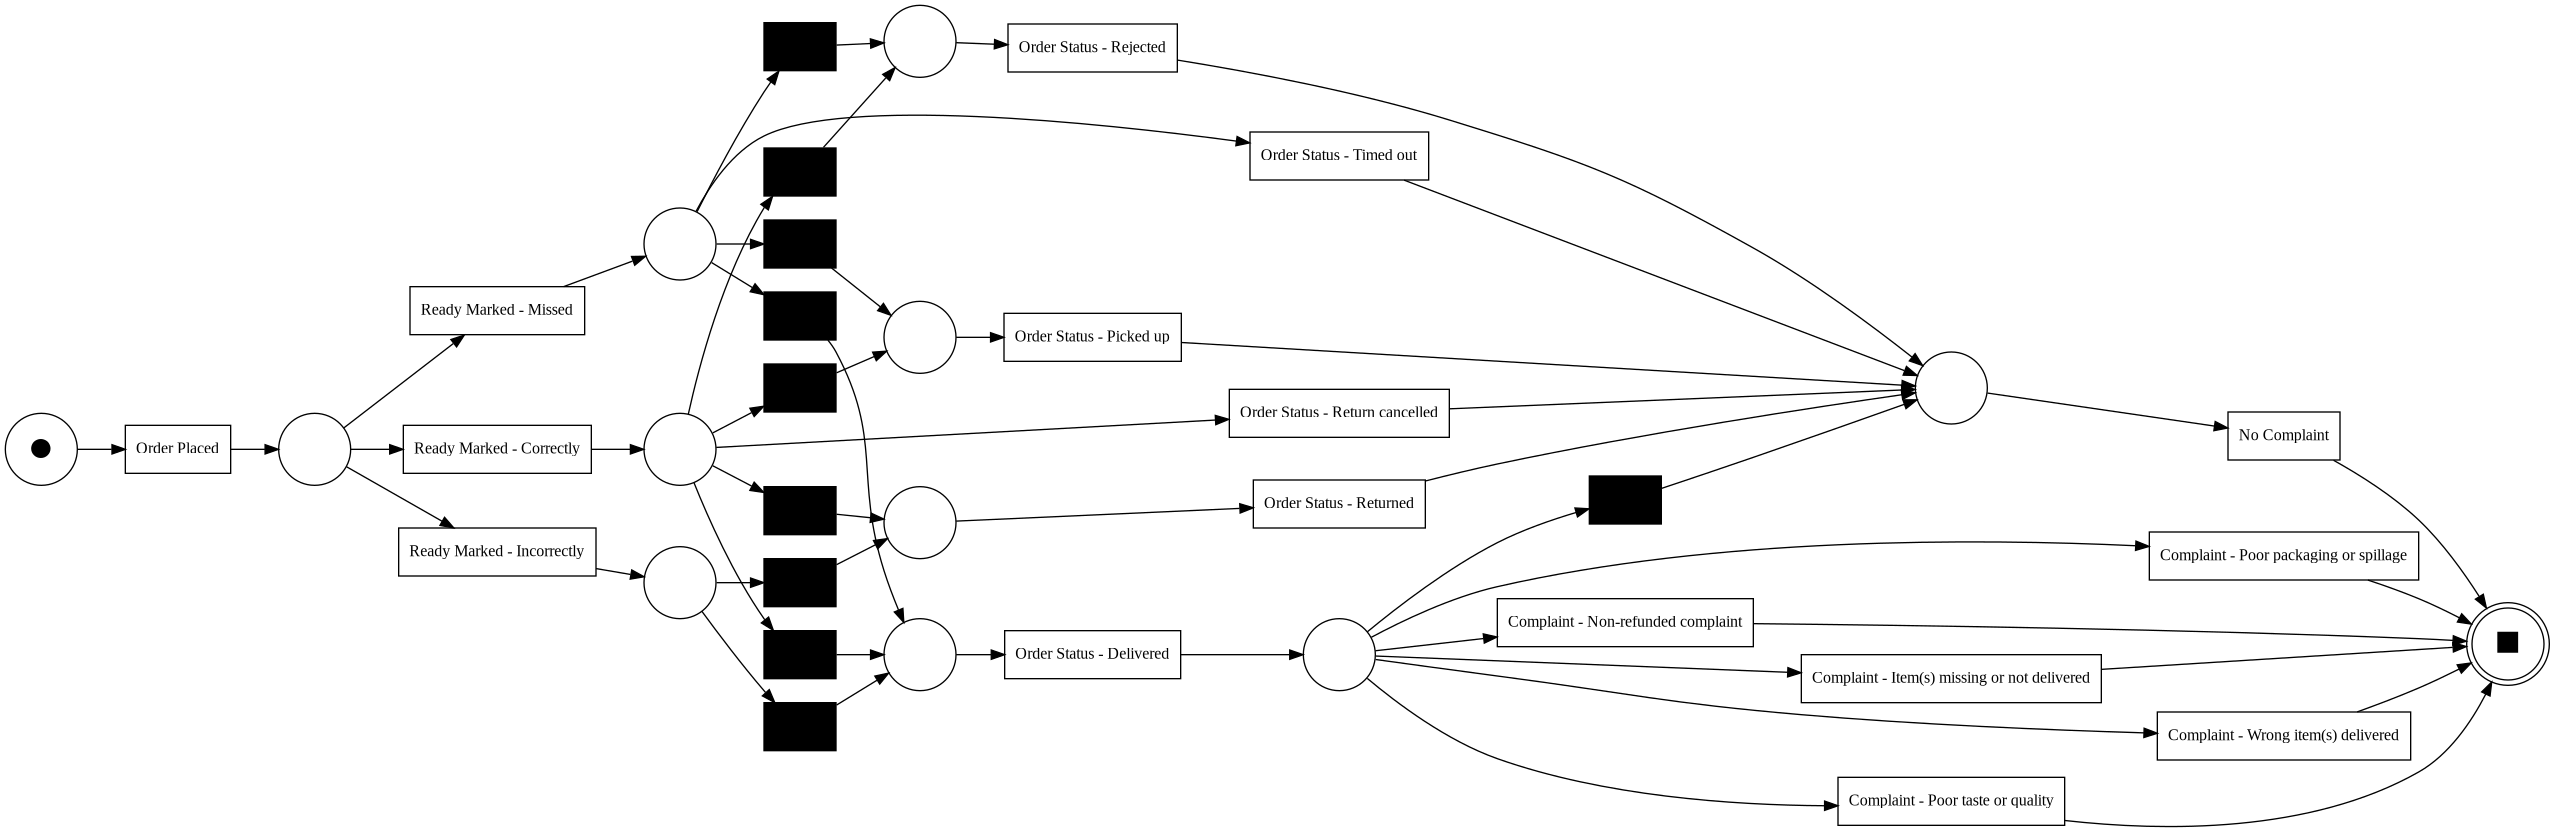

In [ ]:
heu_net, heu_im, heu_fm = \
    pm4py.discover_petri_net_heuristics(full_log)

print("Places:", len(heu_net.places))
print("Transitions:", len(heu_net.transitions))
print("Arcs:", len(heu_net.arcs))

pm4py.view_petri_net(
    heu_net,
    heu_im,
    heu_fm
)

In [ ]:
heu_fitness = pm4py.fitness_token_based_replay(
    full_log, heu_net, heu_im, heu_fm
)

heu_precision = pm4py.precision_token_based_replay(
    full_log, heu_net, heu_im, heu_fm
)

heu_generalization = pm4py.generalization_tbr(
    full_log, heu_net, heu_im, heu_fm
)

heu_simplicity = pm4py.simplicity_petri_net(
    heu_net, heu_im, heu_fm
)

print("Fitness:", heu_fitness["log_fitness"])
print("Precision:", heu_precision)
print("Generalisation:", heu_generalization)
print("Simplicity:", heu_simplicity)

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/16 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

Fitness: 0.9999528863821453
Precision: 1.0
Generalisation: 0.7727007064163463
Simplicity: 0.5757575757575757


In [ ]:
activity_counts = (
    df_full.groupby(["Case ID", "Activity"])
    .size()
)

rework_pairs = activity_counts[activity_counts > 1]

rework_cases = (
    rework_pairs.reset_index()["Case ID"].nunique()
)

total_cases = df_full["Case ID"].nunique()

print("Cases with rework:", rework_cases)
print("Total cases:", total_cases)
print(
    "Rework rate:",
    round((rework_cases / total_cases) * 100, 2),
    "%"
)

Cases with rework: 0
Total cases: 21321
Rework rate: 0.0 %


In [ ]:
from collections import Counter

edges = Counter()

for case_id, group in df_full.groupby("Case ID", sort=False):

    activities = (
        group.sort_values("Event Order")["Activity"]
        .tolist()
    )

    edges.update(
        zip(activities[:-1], activities[1:])
    )

variants = (
    df_full.sort_values(["Case ID", "Event Order"])
    .groupby("Case ID")["Activity"]
    .apply(tuple)
    .nunique()
)

print("Number of distinct DFG edges:", len(edges))
print("Number of process variants:", variants)

Number of distinct DFG edges: 26
Number of process variants: 27
